In [4]:
import requests

url = "https://www.dhlottery.co.kr/common.do?method=getLottoNumber&drwNo=1"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json,text/plain,*/*",
    "Referer": "https://www.dhlottery.co.kr/lt645/result"
}

res = requests.get(url, headers=headers, timeout=10)

print("status_code:", res.status_code)
print("content-type:", res.headers.get("Content-Type"))
print("final_url:", res.url)
print("text 앞 500자:")
print(res.text[:500])

status_code: 200
content-type: text/html; charset=UTF-8
final_url: https://www.dhlottery.co.kr/
text 앞 500자:








<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">


<html xmlns="http://www.w3.org/1999/xhtml" lang="ko" xml:lang="ko">

<script type="text/javascript">
	var rsaModulus = '85671f7fd07c2bd80db535df313897e81410b8d04a38fc4ce9dcebf9454ce73281ea8ac4942976199b655a20582862df32db8599f1b288fae081b7abce4744b11a20bc0ff87d67c3b7ad852a7c7e3b982b8863ed01df308e801141f2557b0d9069069ff2a63b40a41b8706d61876a16c41e60d25a7103152e941f985


In [7]:
import json
import logging
from pathlib import Path
from itertools import combinations

import requests
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules


OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

DATA_URL = "https://smok95.github.io/lotto/results/all.json"

PAIR_MIN_SUPPORT = 0.005
TRIPLE_MIN_SUPPORT = 0.0015
RULE_MIN_CONFIDENCE = 0.08

logging.basicConfig(
    level=logging.INFO,
    format="[%(levelname)s] %(message)s"
)


def load_lotto_all_json() -> pd.DataFrame:
    response = requests.get(
        DATA_URL,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/json,text/plain,*/*"
        },
        timeout=30
    )
    response.raise_for_status()

    text = response.text.strip()

    print("status_code:", response.status_code)
    print("content-type:", response.headers.get("Content-Type"))
    print("text 앞 200자:")
    print(text[:200])

    data = response.json()

    if isinstance(data, dict):
        if "data" in data and isinstance(data["data"], list):
            records = data["data"]
        elif "results" in data and isinstance(data["results"], list):
            records = data["results"]
        else:
            records = list(data.values())
    elif isinstance(data, list):
        records = data
    else:
        raise RuntimeError(f"예상하지 못한 JSON 구조입니다: {type(data)}")

    rows = []

    for item in records:
        if not isinstance(item, dict):
            continue

        draw_no = item.get("draw_no") or item.get("drwNo") or item.get("no")
        numbers = item.get("numbers")

        if numbers is None:
            candidate_keys = [f"drwtNo{i}" for i in range(1, 7)]
            if all(k in item for k in candidate_keys):
                numbers = [item[k] for k in candidate_keys]

        bonus_no = item.get("bonus_no") or item.get("bnusNo") or item.get("bonus")
        date = item.get("date") or item.get("drwNoDate")

        if draw_no is None or numbers is None:
            continue

        numbers = [int(x) for x in numbers]

        if len(numbers) != 6:
            continue

        numbers = sorted(numbers)

        if any(n < 1 or n > 45 for n in numbers):
            continue

        if len(set(numbers)) != 6:
            continue

        rows.append({
            "draw_no": int(draw_no),
            "date": date,
            "n1": numbers[0],
            "n2": numbers[1],
            "n3": numbers[2],
            "n4": numbers[3],
            "n5": numbers[4],
            "n6": numbers[5],
            "bonus": int(bonus_no) if bonus_no is not None else None
        })

    if not rows:
        raise RuntimeError("JSON에서 로또 회차 데이터를 추출하지 못했습니다.")

    df = pd.DataFrame(rows)
    df = df.drop_duplicates(subset=["draw_no"], keep="last")
    df = df.sort_values("draw_no").reset_index(drop=True)

    min_draw = int(df["draw_no"].min())
    max_draw = int(df["draw_no"].max())
    expected_count = max_draw - min_draw + 1

    print(f"수집 회차 범위: {min_draw}회 ~ {max_draw}회")
    print(f"수집 회차 수: {len(df)}")

    if len(df) != expected_count:
        actual = set(df["draw_no"].tolist())
        expected = set(range(min_draw, max_draw + 1))
        missing = sorted(expected - actual)
        print(f"누락 회차 수: {len(missing)}")
        print(f"누락 회차 일부: {missing[:30]}")

    return df


def make_transactions(df: pd.DataFrame) -> list[list[str]]:
    transactions = []

    for _, row in df.iterrows():
        nums = [int(row[f"n{i}"]) for i in range(1, 7)]
        nums = sorted(nums)
        transactions.append([f"N{n:02d}" for n in nums])

    return transactions


def build_onehot(transactions: list[list[str]]) -> pd.DataFrame:
    te = TransactionEncoder()
    ary = te.fit(transactions).transform(transactions)
    return pd.DataFrame(ary, columns=te.columns_)


def extract_itemsets(df_onehot: pd.DataFrame, min_support: float, max_len: int) -> pd.DataFrame:
    freq = apriori(
        df_onehot,
        min_support=min_support,
        use_colnames=True,
        max_len=max_len
    )

    if freq.empty:
        return freq

    freq["length"] = freq["itemsets"].apply(len)

    return freq.sort_values(
        ["length", "support"],
        ascending=[True, False]
    ).reset_index(drop=True)


def extract_pairs_from_freq(freq: pd.DataFrame, total_draws: int) -> pd.DataFrame:
    pairs = freq[freq["itemsets"].apply(len) == 2].copy()

    if pairs.empty:
        return pd.DataFrame(columns=["w1", "w2", "support", "count"])

    pairs[["w1", "w2"]] = pairs["itemsets"].apply(lambda t: pd.Series(sorted(t)))
    pairs["count"] = (pairs["support"] * total_draws).round().astype(int)

    return pairs[["w1", "w2", "support", "count"]].sort_values(
        ["count", "support", "w1", "w2"],
        ascending=[False, False, True, True]
    ).reset_index(drop=True)


def extract_triples_from_freq(freq: pd.DataFrame, total_draws: int) -> pd.DataFrame:
    triples = freq[freq["itemsets"].apply(len) == 3].copy()

    if triples.empty:
        return pd.DataFrame(columns=["w1", "w2", "w3", "support", "count"])

    triples[["w1", "w2", "w3"]] = triples["itemsets"].apply(lambda t: pd.Series(sorted(t)))
    triples["count"] = (triples["support"] * total_draws).round().astype(int)

    return triples[["w1", "w2", "w3", "support", "count"]].sort_values(
        ["count", "support", "w1", "w2", "w3"],
        ascending=[False, False, True, True, True]
    ).reset_index(drop=True)


def number_frequency(df: pd.DataFrame) -> pd.DataFrame:
    values = []

    for _, row in df.iterrows():
        for i in range(1, 7):
            values.append(int(row[f"n{i}"]))

    s = pd.Series(values)

    out = (
        s.value_counts()
        .sort_index()
        .rename_axis("number")
        .reset_index(name="count")
    )

    out["number"] = out["number"].map(lambda x: f"N{x:02d}")

    return out.sort_values(
        ["count", "number"],
        ascending=[False, True]
    ).reset_index(drop=True)


def direct_pair_counter(df: pd.DataFrame) -> pd.DataFrame:
    counter = {}

    for _, row in df.iterrows():
        nums = sorted([int(row[f"n{i}"]) for i in range(1, 7)])

        for a, b in combinations(nums, 2):
            key = (f"N{a:02d}", f"N{b:02d}")
            counter[key] = counter.get(key, 0) + 1

    rows = []
    total = len(df)

    for (a, b), count in counter.items():
        rows.append({
            "w1": a,
            "w2": b,
            "count": count,
            "support": count / total
        })

    return pd.DataFrame(rows).sort_values(
        ["count", "support", "w1", "w2"],
        ascending=[False, False, True, True]
    ).reset_index(drop=True)


def direct_triple_counter(df: pd.DataFrame) -> pd.DataFrame:
    counter = {}

    for _, row in df.iterrows():
        nums = sorted([int(row[f"n{i}"]) for i in range(1, 7)])

        for a, b, c in combinations(nums, 3):
            key = (f"N{a:02d}", f"N{b:02d}", f"N{c:02d}")
            counter[key] = counter.get(key, 0) + 1

    rows = []
    total = len(df)

    for (a, b, c), count in counter.items():
        rows.append({
            "w1": a,
            "w2": b,
            "w3": c,
            "count": count,
            "support": count / total
        })

    return pd.DataFrame(rows).sort_values(
        ["count", "support", "w1", "w2", "w3"],
        ascending=[False, False, True, True, True]
    ).reset_index(drop=True)


def build_rules(freq: pd.DataFrame, total_draws: int) -> pd.DataFrame:
    if freq.empty:
        return pd.DataFrame()

    rules = association_rules(
        freq,
        metric="confidence",
        min_threshold=RULE_MIN_CONFIDENCE
    )

    if rules.empty:
        return rules

    rules["antecedents_text"] = rules["antecedents"].apply(lambda x: ",".join(sorted(x)))
    rules["consequents_text"] = rules["consequents"].apply(lambda x: ",".join(sorted(x)))
    rules["count"] = (rules["support"] * total_draws).round().astype(int)

    return rules[
        [
            "antecedents_text",
            "consequents_text",
            "support",
            "count",
            "confidence",
            "lift",
            "leverage",
            "conviction"
        ]
    ].sort_values(
        ["lift", "confidence", "count"],
        ascending=[False, False, False]
    ).reset_index(drop=True)


draws = load_lotto_all_json()
total_draws = len(draws)
latest_draw = int(draws["draw_no"].max())

draws_path = OUT_DIR / f"lotto_draws_1_to_{latest_draw}.csv"
draws.to_csv(draws_path, index=False, encoding="utf-8-sig")

transactions = make_transactions(draws)
onehot = build_onehot(transactions)

onehot_path = OUT_DIR / f"lotto_onehot_1_to_{latest_draw}.csv"
onehot.to_csv(onehot_path, index=False, encoding="utf-8-sig")

freq_numbers = number_frequency(draws)
freq_numbers.to_csv(OUT_DIR / "number_frequency.csv", index=False, encoding="utf-8-sig")

freq_pairs_base = extract_itemsets(
    df_onehot=onehot,
    min_support=PAIR_MIN_SUPPORT,
    max_len=2
)

top_pairs = extract_pairs_from_freq(freq_pairs_base, total_draws)
top_pairs.to_csv(OUT_DIR / "top_pairs_by_support.csv", index=False, encoding="utf-8-sig")

direct_pairs = direct_pair_counter(draws)
direct_pairs.to_csv(OUT_DIR / "top_pairs_direct_count.csv", index=False, encoding="utf-8-sig")

freq_triples_base = extract_itemsets(
    df_onehot=onehot,
    min_support=TRIPLE_MIN_SUPPORT,
    max_len=3
)

top_triples = extract_triples_from_freq(freq_triples_base, total_draws)
top_triples.to_csv(OUT_DIR / "top_triples_by_support.csv", index=False, encoding="utf-8-sig")

direct_triples = direct_triple_counter(draws)
direct_triples.to_csv(OUT_DIR / "top_triples_direct_count.csv", index=False, encoding="utf-8-sig")

rules = build_rules(freq_triples_base, total_draws)
rules.to_csv(OUT_DIR / "association_rules.csv", index=False, encoding="utf-8-sig")

print("\n" + "=" * 80)
print(f"분석 기준: 로또 6/45 {int(draws['draw_no'].min())}회 ~ {latest_draw}회")
print(f"분석 회차 수: {total_draws}")
print("보너스 번호는 제외하고 6개 당첨번호만 분석했습니다.")
print("=" * 80)

print("\n[숫자별 출현 빈도 TOP 20]")
display(freq_numbers.head(20))

print("\n[함께 많이 나온 2개 숫자 조합 TOP 30: PDF Apriori support 기준]")
display(top_pairs.head(30))

print("\n[함께 많이 나온 2개 숫자 조합 TOP 30: 직접 카운트 검증]")
display(direct_pairs.head(30))

print("\n[함께 많이 나온 3개 숫자 조합 TOP 30: PDF Apriori support 기준]")
display(top_triples.head(30))

print("\n[함께 많이 나온 3개 숫자 조합 TOP 30: 직접 카운트 검증]")
display(direct_triples.head(30))

print("\n[lift 높은 연관규칙 TOP 30]")
if rules.empty:
    print("조건에 맞는 연관규칙이 없습니다.")
else:
    display(rules.head(30))

print("\n[저장 파일]")
print(draws_path)
print(onehot_path)
print(OUT_DIR / "number_frequency.csv")
print(OUT_DIR / "top_pairs_by_support.csv")
print(OUT_DIR / "top_pairs_direct_count.csv")
print(OUT_DIR / "top_triples_by_support.csv")
print(OUT_DIR / "top_triples_direct_count.csv")
print(OUT_DIR / "association_rules.csv")

status_code: 200
content-type: application/json; charset=utf-8
text 앞 200자:
[
{"draw_no":1,"numbers":[10,23,29,33,37,40],"bonus_no":16,"date":"2002-12-07T00:00:00Z","divisions":[{},{"prize":143934100,"winners":1},{"prize":5140500,"winners":28},{"prize":113400,"winners":2537},
수집 회차 범위: 1회 ~ 1225회
수집 회차 수: 1225

분석 기준: 로또 6/45 1회 ~ 1225회
분석 회차 수: 1225
보너스 번호는 제외하고 6개 당첨번호만 분석했습니다.

[숫자별 출현 빈도 TOP 20]


,number,count
0,N34,182
1,N27,181
2,N12,177
3,N13,176
4,N18,175
5,N45,175
6,N33,174
7,N40,172
8,N03,171
9,N37,171



[함께 많이 나온 2개 숫자 조합 TOP 30: PDF Apriori support 기준]


,w1,w2,support,count
0,N11,N21,0.027755,34
1,N33,N40,0.026939,33
2,N06,N38,0.025306,31
3,N01,N28,0.024490,30
4,N10,N31,0.024490,30
5,N12,N24,0.024490,30
6,N03,N13,0.023673,29
7,N03,N20,0.023673,29
8,N03,N24,0.023673,29
9,N14,N15,0.023673,29



[함께 많이 나온 2개 숫자 조합 TOP 30: 직접 카운트 검증]


...


[함께 많이 나온 3개 숫자 조합 TOP 30: 직접 카운트 검증]


,w1,w2,w3,count,support
0,N01,N03,N27,8,0.006531
1,N03,N08,N27,8,0.006531
2,N03,N20,N44,8,0.006531
3,N33,N37,N40,8,0.006531
4,N02,N25,N28,7,0.005714
5,N03,N12,N13,7,0.005714
6,N03,N20,N24,7,0.005714
7,N03,N32,N45,7,0.005714
8,N06,N11,N17,7,0.005714
9,N06,N18,N38,7,0.005714



[lift 높은 연관규칙 TOP 30]


,antecedents_text,consequents_text,support,count,confidence,lift,leverage,conviction
0,"N18,N41",N30,0.004898,6,0.500000,3.901274,0.003642,1.743673
1,"N23,N33",N29,0.004082,5,0.454545,3.639335,0.002960,1.604354
2,"N08,N12",N29,0.002449,3,0.428571,3.431373,0.001735,1.531429
3,"N08,N12",N42,0.002449,3,0.428571,3.387097,0.001726,1.528571
4,"N02,N38",N01,0.004898,6,0.461538,3.365385,0.003443,1.602449
5,"N02,N23",N15,0.004082,5,0.454545,3.334241,0.002857,1.583401
6,"N03,N44",N20,0.006531,8,0.444444,3.221565,0.004503,1.551673
7,"N10,N39",N11,0.004898,6,0.428571,3.181818,0.003359,1.514286
8,"N11,N34",N42,0.003265,4,0.400000,3.161290,0.002232,1.455782
9,"N24,N43",N23,0.002449,3,0.375000,3.125000,0.001665,1.408000



[저장 파일]
out\lotto_draws_1_to_1225.csv
out\lotto_onehot_1_to_1225.csv
out\number_frequency.csv
out\top_pairs_by_support.csv
out\top_pairs_direct_count.csv
out\top_triples_by_support.csv
out\top_triples_direct_count.csv
out\association_rules.csv


In [9]:
import pandas as pd
from pathlib import Path

# 1) 저장된 로또 전체 회차 데이터 불러오기
csv_path = Path("out/lotto_draws_1_to_1225.csv")

if not csv_path.exists():
    raise FileNotFoundError(
        "out/lotto_draws_1_to_1225.csv 파일이 없습니다. "
        "먼저 로또 데이터 수집/분석 코드를 실행해서 CSV를 생성하세요."
    )

draws = pd.read_csv(csv_path)

# 2) 확인할 5개 추천 조합 재정의
target_lines = {
    "1순위": [1, 3, 27, 33, 37, 40],
    "2순위": [3, 11, 21, 27, 33, 40],
    "3순위": [12, 24, 27, 33, 34, 40],
    "4순위": [3, 12, 15, 24, 34, 45],
    "5순위": [6, 18, 33, 37, 38, 40],
}

# 3) 정확히 6개 번호가 과거에 그대로 나온 적 있는지 확인
exact_results = []

for rank, nums in target_lines.items():
    nums_sorted = sorted(nums)

    matched = draws[
        draws[["n1", "n2", "n3", "n4", "n5", "n6"]]
        .apply(lambda row: sorted(row.astype(int).tolist()) == nums_sorted, axis=1)
    ]

    if len(matched) > 0:
        for _, row in matched.iterrows():
            exact_results.append({
                "순위": rank,
                "추천조합": ", ".join(map(str, nums_sorted)),
                "정확히_6개_출현여부": "나온 적 있음",
                "회차": int(row["draw_no"]),
                "날짜": row["date"],
                "실제번호": ", ".join(map(str, nums_sorted)),
                "보너스": int(row["bonus"]) if pd.notna(row["bonus"]) else None
            })
    else:
        exact_results.append({
            "순위": rank,
            "추천조합": ", ".join(map(str, nums_sorted)),
            "정확히_6개_출현여부": "나온 적 없음",
            "회차": "",
            "날짜": "",
            "실제번호": "",
            "보너스": ""
        })

exact_df = pd.DataFrame(exact_results)

print("[추천 5개 조합이 과거에 정확히 그대로 나온 적 있는지]")
display(exact_df)

# 4) 과거 회차와 4개 이상 겹친 적 있는지 확인
near_results = []

for rank, nums in target_lines.items():
    target_set = set(nums)

    for _, row in draws.iterrows():
        draw_nums = {int(row[f"n{i}"]) for i in range(1, 7)}
        matched_nums = sorted(target_set & draw_nums)
        match_count = len(matched_nums)

        if match_count >= 4:
            near_results.append({
                "순위": rank,
                "추천조합": ", ".join(map(str, sorted(nums))),
                "일치개수": match_count,
                "일치번호": ", ".join(map(str, matched_nums)),
                "회차": int(row["draw_no"]),
                "날짜": row["date"],
                "실제번호": ", ".join(map(str, sorted(draw_nums))),
                "보너스": int(row["bonus"]) if pd.notna(row["bonus"]) else None
            })

near_df = pd.DataFrame(near_results)

print("\n[추천 5개 조합과 과거 회차가 4개 이상 겹친 사례]")
if near_df.empty:
    print("5개 라인업 중 과거 회차와 4개 이상 겹친 사례가 없습니다.")
else:
    near_df = near_df.sort_values(
        ["일치개수", "순위", "회차"],
        ascending=[False, True, False]
    ).reset_index(drop=True)

    display(near_df)

# 5) 요약표: 각 추천 조합별 최대 몇 개까지 과거 회차와 겹쳤는지
summary_rows = []

for rank, nums in target_lines.items():
    target_set = set(nums)
    best_match_count = 0
    best_rows = []

    for _, row in draws.iterrows():
        draw_nums = {int(row[f"n{i}"]) for i in range(1, 7)}
        matched_nums = sorted(target_set & draw_nums)
        match_count = len(matched_nums)

        if match_count > best_match_count:
            best_match_count = match_count
            best_rows = [{
                "회차": int(row["draw_no"]),
                "날짜": row["date"],
                "일치번호": ", ".join(map(str, matched_nums)),
                "실제번호": ", ".join(map(str, sorted(draw_nums))),
                "보너스": int(row["bonus"]) if pd.notna(row["bonus"]) else None
            }]
        elif match_count == best_match_count:
            best_rows.append({
                "회차": int(row["draw_no"]),
                "날짜": row["date"],
                "일치번호": ", ".join(map(str, matched_nums)),
                "실제번호": ", ".join(map(str, sorted(draw_nums))),
                "보너스": int(row["bonus"]) if pd.notna(row["bonus"]) else None
            })

    recent_best = sorted(best_rows, key=lambda x: x["회차"], reverse=True)[0]

    summary_rows.append({
        "순위": rank,
        "추천조합": ", ".join(map(str, sorted(nums))),
        "과거_최대_일치개수": best_match_count,
        "대표회차": recent_best["회차"],
        "날짜": recent_best["날짜"],
        "일치번호": recent_best["일치번호"],
        "해당회차_실제번호": recent_best["실제번호"],
        "보너스": recent_best["보너스"]
    })

summary_df = pd.DataFrame(summary_rows)

print("\n[조합별 과거 최대 일치 개수 요약]")
display(summary_df)

[추천 5개 조합이 과거에 정확히 그대로 나온 적 있는지]


,순위,추천조합,정확히_6개_출현여부,회차,날짜,실제번호,보너스
0,1순위,"1, 3, 27, 33, 37, 40",나온 적 없음,,,,
1,2순위,"3, 11, 21, 27, 33, 40",나온 적 없음,,,,
2,3순위,"12, 24, 27, 33, 34, 40",나온 적 없음,,,,
3,4순위,"3, 12, 15, 24, 34, 45",나온 적 없음,,,,
4,5순위,"6, 18, 33, 37, 38, 40",나온 적 없음,,,,



[추천 5개 조합과 과거 회차가 4개 이상 겹친 사례]


,순위,추천조합,일치개수,일치번호,회차,날짜,실제번호,보너스
0,1순위,"1, 3, 27, 33, 37, 40",4,"1, 33, 37, 40",714,2016-08-06T00:00:00Z,"1, 7, 22, 33, 37, 40",20
1,1순위,"1, 3, 27, 33, 37, 40",4,"1, 27, 37, 40",263,2007-12-15T00:00:00Z,"1, 27, 28, 32, 37, 40",18
2,1순위,"1, 3, 27, 33, 37, 40",4,"1, 3, 27, 37",99,2004-10-23T00:00:00Z,"1, 3, 10, 27, 29, 37",11
3,2순위,"3, 11, 21, 27, 33, 40",4,"11, 21, 27, 33",979,2021-09-04T00:00:00Z,"7, 11, 16, 21, 27, 33",24
4,2순위,"3, 11, 21, 27, 33, 40",4,"3, 11, 21, 33",698,2016-04-16T00:00:00Z,"3, 11, 13, 21, 33, 37",18
5,3순위,"12, 24, 27, 33, 34, 40",4,"12, 24, 33, 40",453,2011-08-06T00:00:00Z,"12, 24, 33, 38, 40, 42",30
6,4순위,"3, 12, 15, 24, 34, 45",4,"3, 12, 15, 34",1144,2024-11-02T00:00:00Z,"3, 4, 12, 15, 26, 34",6
7,4순위,"3, 12, 15, 24, 34, 45",4,"12, 15, 24, 45",1021,2022-06-25T00:00:00Z,"12, 15, 17, 24, 29, 45",16
8,4순위,"3, 12, 15, 24, 34, 45",4,"12, 24, 34, 45",749,2017-04-08T00:00:00Z,"12, 14, 24, 26, 34, 45",41
9,4순위,"3, 12, 15, 24, 34, 45",4,"3, 12, 15, 34",540,2013-04-06T00:00:00Z,"3, 12, 13, 15, 34, 36",14



[조합별 과거 최대 일치 개수 요약]


,순위,추천조합,과거_최대_일치개수,대표회차,날짜,일치번호,해당회차_실제번호,보너스
0,1순위,"1, 3, 27, 33, 37, 40",4,714,2016-08-06T00:00:00Z,"1, 33, 37, 40","1, 7, 22, 33, 37, 40",20
1,2순위,"3, 11, 21, 27, 33, 40",4,979,2021-09-04T00:00:00Z,"11, 21, 27, 33","7, 11, 16, 21, 27, 33",24
2,3순위,"12, 24, 27, 33, 34, 40",4,453,2011-08-06T00:00:00Z,"12, 24, 33, 40","12, 24, 33, 38, 40, 42",30
3,4순위,"3, 12, 15, 24, 34, 45",4,1144,2024-11-02T00:00:00Z,"3, 12, 15, 34","3, 4, 12, 15, 26, 34",6
4,5순위,"6, 18, 33, 37, 38, 40",4,1180,2025-07-12T00:00:00Z,"6, 18, 37, 40","6, 12, 18, 37, 40, 41",3


In [5]:
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer


CSV_PATH = Path(
    r"C:\Users\itwill\자동화 공부\개인프로젝트\네이버쇼핑\결과 추출\2026-05-27-14-47-10-리얼베리어 세라마이드 클렌징 밀크 200ml, 1개\2026-05-27-14-47-10-리얼베리어 세라마이드 클렌징 밀크 200ml, 1개.csv"
)

BASE_DIR = CSV_PATH.parent
OUT_DIR = BASE_DIR / "output_csv"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TEXT_COL = "리뷰 내용"
RATING_COL = "개별 평점"


STOPWORDS = {
    "너무", "정말", "진짜", "그리고", "하지만", "이런", "저런", "제품", "상품",
    "구매", "생각", "조금", "것", "거", "좀", "정도", "그냥", "하게",
    "있어요", "다음", "여러", "있습니다", "있는", "해서", "때문", "이번",
    "그런", "이렇게", "저렇게", "있다", "찾다", "하다", "먹다", "높다",
    "바쁘다", "돼다", "재다", "되다", "자다", "들다", "가다", "쓸다",
    "거의", "리뷰", "후기", "완전", "아주", "약간", "많이", "괜찮아요",
    "좋아요", "좋습니다", "좋네요", "같아요", "입니다", "합니다", "했어요",
    "받았어요", "써봤어요", "구매했어요", "사용했어요", "감사합니다",
    "잘", "사용", "클렌징", "밀크", "리얼베리어", "세라마이드"
}


ASPECT_RULES = {
    "여행/휴대": [
        "여행", "휴대", "출장", "사이즈", "작", "미니", "30ml",
        "소용량", "체험", "샘플", "아담"
    ],
    "자극/민감": [
        "자극", "순하", "민감", "예민", "피부염", "붉", "가렵", "따갑",
        "소양감", "트러블", "부담"
    ],
    "보습/당김": [
        "촉촉", "건조", "당김", "보습", "장벽", "수분", "편안"
    ],
    "세정력": [
        "세정", "지워", "닦", "메이크업", "선크림", "마스카라", "립스틱",
        "아이라이너", "노폐물", "잔여물", "이중세안"
    ],
    "사용감/제형": [
        "부드럽", "뻑뻑", "미끄", "롤링", "유화", "밀착", "로션",
        "꾸덕", "거품", "마무리감", "막", "잔여감", "오일"
    ],
    "가격/딜": [
        "저렴", "가격", "딜", "행사", "할인", "가성비", "특가", "라이브"
    ],
    "배송": [
        "배송", "발송", "도착", "빠름", "빨라"
    ],
    "재구매/본품": [
        "재구매", "본품", "정착", "추천", "또 구매", "주문", "구입",
        "쟁여", "사려", "사고싶"
    ],
    "향": [
        "향", "냄새", "무향"
    ]
}


POSITIVE_WORDS = [
    "좋", "만족", "추천", "촉촉", "순하", "부드럽", "빠르", "빨라",
    "저렴", "괜찮", "편하", "믿고", "대만족", "정착", "깨끗",
    "안심", "부담 없", "자극 없"
]

NEGATIVE_WORDS = [
    "아쉽", "별로", "작", "약하", "딸리", "뻑뻑", "미끄", "강한",
    "강하", "안", "않", "못", "실망", "최악", "소양감", "느리",
    "파손", "누락", "부담", "잔여감", "막", "시렵", "맵"
]


NORMALIZE_MAP = {
    "클린징": "클렌징",
    "클랜징": "클렌징",
    "리얼배리어": "리얼베리어",
    "리얼 베리어": "리얼베리어",
    "자극없이": "자극 없음",
    "자극없고": "자극 없음",
    "자극없어서": "자극 없음",
    "자극없음": "자극 없음",
    "자극업이": "자극 없이",
    "잘지워": "잘 지워",
    "잘 지워져": "잘 지워",
    "지워져": "지워",
    "지워지는": "지워",
    "촉촉하고": "촉촉",
    "촉촉하": "촉촉",
    "여행용": "여행 용",
    "휴대용": "휴대 용",
    "체험딜": "체험 딜",
    "본품사": "본품 사",
    "선 크림": "선크림",
    "썬크림": "선크림",
    "이중세안": "이중 세안",
}


def read_csv_safely(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"CSV 파일이 없습니다: {path}")

    for enc in ["utf-8-sig", "utf-8", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue

    raise UnicodeDecodeError("CSV 인코딩을 확인하세요.")


def normalize_text(text: str) -> str:
    text = str(text).lower()
    for src, dst in NORMALIZE_MAP.items():
        text = text.replace(src, dst)
    return text


def clean_text(text: str) -> str:
    text = normalize_text(text)
    text = re.sub(r"[^0-9a-z가-힣\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text: str) -> list[str]:
    text = clean_text(text)
    tokens = text.split()
    return [
        token for token in tokens
        if len(token) >= 2
        and token not in STOPWORDS
        and not token.isdigit()
    ]


def classify_aspects(text: str) -> list[str]:
    hits = []
    for aspect, keywords in ASPECT_RULES.items():
        if any(keyword in text for keyword in keywords):
            hits.append(aspect)
    return hits if hits else ["기타"]


def classify_sentiment(text: str) -> str:
    pos_score = sum(1 for word in POSITIVE_WORDS if word in text)
    neg_score = sum(1 for word in NEGATIVE_WORDS if word in text)

    if pos_score > neg_score:
        return "긍정"
    if neg_score > pos_score:
        return "부정/주의"
    return "중립"


def make_tfidf(df: pd.DataFrame) -> pd.DataFrame:
    docs = df["cleaned_text"].tolist()

    vectorizer = TfidfVectorizer(
        tokenizer=tokenize,
        token_pattern=None,
        ngram_range=(1, 3),
        min_df=1,
        max_df=0.85,
    )

    X = vectorizer.fit_transform(docs)
    terms = vectorizer.get_feature_names_out()
    scores = X.sum(axis=0).A1

    result = pd.DataFrame({"term": terms, "score": scores})
    result = result.sort_values("score", ascending=False).reset_index(drop=True)
    return result


def make_count(df: pd.DataFrame) -> pd.DataFrame:
    docs = [" ".join(tokenize(text)) for text in df["cleaned_text"].tolist()]

    vectorizer = CountVectorizer(
        token_pattern=r"(?u)\b[0-9a-z가-힣]{2,}\b",
        ngram_range=(1, 3),
        min_df=1,
    )

    X = vectorizer.fit_transform(docs)
    terms = vectorizer.get_feature_names_out()
    counts = np.asarray(X.sum(axis=0)).ravel()

    result = pd.DataFrame({"term": terms, "count": counts})
    result = result.sort_values("count", ascending=False).reset_index(drop=True)
    return result


def make_aspect_detail(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in df.iterrows():
        review_no = row["번호"] if "번호" in df.columns else None
        rating = row[RATING_COL]
        text = row[TEXT_COL]
        cleaned = row["cleaned_text"]
        aspects = classify_aspects(cleaned)
        sentiment = classify_sentiment(cleaned)

        for aspect in aspects:
            rows.append({
                "번호": review_no,
                "개별 평점": rating,
                "aspect": aspect,
                "sentiment": sentiment,
                "리뷰 내용": text,
            })

    return pd.DataFrame(rows)


def main():
    print("[1] CSV 불러오는 중...")
    df = read_csv_safely(CSV_PATH)

    print("[확인] 컬럼:", list(df.columns))
    print("[확인] 원본 행 수:", len(df))

    if TEXT_COL not in df.columns:
        raise ValueError(f"'{TEXT_COL}' 컬럼이 없습니다. 현재 컬럼: {list(df.columns)}")

    if RATING_COL not in df.columns:
        raise ValueError(f"'{RATING_COL}' 컬럼이 없습니다. 현재 컬럼: {list(df.columns)}")

    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
    df[RATING_COL] = pd.to_numeric(df[RATING_COL], errors="coerce")
    df = df[df[TEXT_COL].str.strip().ne("")].copy()
    df["cleaned_text"] = df[TEXT_COL].apply(clean_text)

    print("[확인] 분석 리뷰 수:", len(df))
    print("[확인] 평균 평점:", round(df[RATING_COL].mean(), 3))
    print("[확인] 평점 분포")
    print(df[RATING_COL].value_counts().sort_index().to_string())

    print("\n[2] TF-IDF 키워드/구문 분석 중...")
    tfidf_df = make_tfidf(df)
    tfidf_df.to_csv(OUT_DIR / "01_keywords_tfidf_top300.csv", index=False, encoding="utf-8-sig")

    print("\n[3] 단순 빈도 키워드/구문 분석 중...")
    count_df = make_count(df)
    count_df.to_csv(OUT_DIR / "02_keywords_count_top300.csv", index=False, encoding="utf-8-sig")

    phrase_df = tfidf_df[tfidf_df["term"].str.contains(" ", regex=False)].copy()
    phrase_df.to_csv(OUT_DIR / "03_phrases_tfidf_top300.csv", index=False, encoding="utf-8-sig")

    print("\n[4] 속성별 분류 중...")
    aspect_detail = make_aspect_detail(df)
    aspect_detail.to_csv(OUT_DIR / "04_aspect_review_detail.csv", index=False, encoding="utf-8-sig")

    aspect_summary = (
        aspect_detail
        .groupby(["aspect", "sentiment"], as_index=False)
        .agg(
            review_count=("리뷰 내용", "count"),
            avg_rating=("개별 평점", "mean"),
        )
        .sort_values(["aspect", "review_count"], ascending=[True, False])
        .reset_index(drop=True)
    )
    aspect_summary.to_csv(OUT_DIR / "05_aspect_sentiment_summary.csv", index=False, encoding="utf-8-sig")

    aspect_total = (
        aspect_detail
        .groupby("aspect", as_index=False)
        .agg(
            review_count=("리뷰 내용", "count"),
            avg_rating=("개별 평점", "mean"),
        )
        .sort_values("review_count", ascending=False)
        .reset_index(drop=True)
    )
    aspect_total.to_csv(OUT_DIR / "06_aspect_total_summary.csv", index=False, encoding="utf-8-sig")

    low_rating_df = df[df[RATING_COL] <= 3].copy()
    low_rating_df.to_csv(OUT_DIR / "07_low_rating_reviews.csv", index=False, encoding="utf-8-sig")

    print("\n" + "=" * 80)
    print("[TF-IDF TOP 30]")
    print(tfidf_df.head(30).to_string(index=False))

    print("\n" + "=" * 80)
    print("[핵심 구문 TOP 30]")
    print(phrase_df.head(30).to_string(index=False))

    print("\n" + "=" * 80)
    print("[속성별 전체 요약]")
    print(aspect_total.to_string(index=False))

    print("\n" + "=" * 80)
    print("[낮은 평점 리뷰]")
    if low_rating_df.empty:
        print("평점 3점 이하 리뷰가 없습니다.")
    else:
        print(low_rating_df[["번호", RATING_COL, TEXT_COL]].to_string(index=False))

    print("\n" + "=" * 80)
    print("분석 완료")
    print("저장 폴더:", OUT_DIR)
    print("=" * 80)
    print("1.", OUT_DIR / "01_keywords_tfidf_top300.csv")
    print("2.", OUT_DIR / "02_keywords_count_top300.csv")
    print("3.", OUT_DIR / "03_phrases_tfidf_top300.csv")
    print("4.", OUT_DIR / "04_aspect_review_detail.csv")
    print("5.", OUT_DIR / "05_aspect_sentiment_summary.csv")
    print("6.", OUT_DIR / "06_aspect_total_summary.csv")
    print("7.", OUT_DIR / "07_low_rating_reviews.csv")


if __name__ == "__main__":
    main()

[1] CSV 불러오는 중...
[확인] 컬럼: ['번호', '개별 평점', '리뷰 내용']
[확인] 원본 행 수: 200
[확인] 분석 리뷰 수: 200
[확인] 평균 평점: 4.825
[확인] 평점 분포
개별 평점
2      1
3      7
4     18
5    174

[2] TF-IDF 키워드/구문 분석 중...

[3] 단순 빈도 키워드/구문 분석 중...

[4] 속성별 분류 중...

[TF-IDF TOP 30]
  term    score
    여행 4.574228
   용으로 4.308304
여행 용으로 3.858904
    좋은 2.152418
   써보고 1.973424
    자극 1.973239
  저렴하게 1.958319
   있어서 1.898891
    배송 1.824352
   작아서 1.809975
    아직 1.790213
 클렌징밀크 1.659710
  생각보다 1.536256
 만족합니다 1.515192
    믿고 1.489839
    체험 1.473636
    없음 1.464319
    촉촉 1.461623
 자극 없음 1.430377
   샀어요 1.422662
   피부에 1.222507
    쓰기 1.213336
  여행갈때 1.192297
    처음 1.181294
   싶어서 1.173489
   크기가 1.139879
구매했습니다 1.108279
  세정력이 1.099968
   자극이 1.086879
  부드럽게 1.068091

[핵심 구문 TOP 30]
                term    score
              여행 용으로 3.858904
               자극 없음 1.430377
              휴대 용으로 0.943894
           싶어서 주문했어요 0.791715
               자극 없이 0.770214
               체험 딜로 0.751004
               빠른 배송 0.723118
   

In [6]:
pip install pandas scikit-learn numpy openpyxl konlpy jpype1


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer


CSV_PATH = Path(
    r"C:\Users\itwill\자동화 공부\개인프로젝트\네이버쇼핑\결과 추출\2026-05-27-14-47-10-리얼베리어 세라마이드 클렌징 밀크 200ml, 1개\2026-05-27-14-47-10-리얼베리어 세라마이드 클렌징 밀크 200ml, 1개.csv"
)

BASE_DIR = CSV_PATH.parent
STOPWORDS_PATH = BASE_DIR / "stopwords.txt"
OUT_DIR = BASE_DIR / "pdf_style_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TEXT_COL = "리뷰 내용"


def read_csv_safely(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"CSV 파일을 찾을 수 없습니다: {path}")

    for enc in ["utf-8-sig", "utf-8", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue

    raise ValueError("CSV 인코딩을 확인하세요. utf-8-sig, utf-8, cp949 모두 실패했습니다.")


def read_stopwords(path: Path) -> set[str]:
    default_stopwords = {
        "너무", "정말", "진짜", "그리고", "하지만", "이런", "저런",
        "제품", "상품", "구매", "생각", "조금", "것", "거", "좀",
        "정도", "그냥", "하게", "있어요", "다음", "여러", "있습니다",
        "있는", "해서", "때문", "이번", "그런", "이렇게", "저렇게",
        "있다", "찾다", "하다", "먹다", "바쁘다", "돼다", "재다",
        "되다", "자다", "들다", "가다", "쓸다", "거의",
        "리뷰", "후기", "완전", "아주", "약간", "많이",
        "괜찮아요", "좋아요", "좋습니다", "좋네요", "좋은", "좋고",
        "좋아서", "같아요", "같네요", "입니다", "합니다", "했어요",
        "받았어요", "받았습니다", "써봤어요", "써보고", "써보니",
        "써봤는데", "구매했어요", "사용했어요", "감사합니다",
        "쓸게요", "쓸께요", "듯요", "넘", "매우", "우선", "일단",
        "아직", "사용전", "주문", "구입", "샀어요", "사봤어요",
        "용으로", "용도", "잘", "사용"
    }

    if not path.exists():
        print(f"[경고] stopwords.txt 파일이 없습니다: {path}")
        print("[처리] 기본 불용어를 사용합니다.")
        return default_stopwords

    for enc in ["utf-8-sig", "utf-8", "cp949"]:
        try:
            text = path.read_text(encoding=enc)
            file_stopwords = {w.strip() for w in text.splitlines() if w.strip()}
            return default_stopwords.union(file_stopwords)
        except UnicodeDecodeError:
            continue

    print("[경고] stopwords.txt 인코딩을 읽지 못했습니다. 기본 불용어만 사용합니다.")
    return default_stopwords


NORMALIZE_MAP = {
    "클린징": "클렌징",
    "클랜징": "클렌징",
    "리얼배리어": "리얼베리어",
    "리얼 베리어": "리얼베리어",
    "자극없이": "자극 없음",
    "자극없고": "자극 없음",
    "자극없어서": "자극 없음",
    "자극없음": "자극 없음",
    "자극업이": "자극 없이",
    "잘지워": "잘 지워",
    "잘 지워져": "잘 지워",
    "지워져": "지워",
    "지워지는": "지워",
    "촉촉하고": "촉촉",
    "촉촉하": "촉촉",
    "체험딜": "체험 딜",
    "본품사": "본품 사",
    "선 크림": "선크림",
    "썬크림": "선크림",
    "이중세안": "이중 세안",
    "30미리": "30ml",
}


def normalize_text(s: str) -> str:
    s = str(s).lower()
    for src, dst in NORMALIZE_MAP.items():
        s = s.replace(src, dst)
    return s


def clean_text(s: str) -> str:
    s = normalize_text(s)
    s = re.sub(r"[^0-9a-z가-힣\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def save_txt_docs(docs: list[str], path: Path) -> None:
    path.write_text("\n".join(docs), encoding="utf-8-sig")


def run_tfidf_ngram(docs: list[str], stopwords: set[str]) -> pd.DataFrame:
    vectorizer = TfidfVectorizer(
        stop_words=list(stopwords),
        ngram_range=(1, 3),
        token_pattern=r"(?u)\b[0-9a-z가-힣]{2,}\b",
        min_df=1,
    )

    X = vectorizer.fit_transform(docs)
    terms = vectorizer.get_feature_names_out()
    scores = X.sum(axis=0).A1

    df = pd.DataFrame({"term": terms, "score": scores})
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    return df


def run_count_ngram(docs: list[str], stopwords: set[str]) -> pd.DataFrame:
    cv = CountVectorizer(
        stop_words=list(stopwords),
        ngram_range=(1, 3),
        token_pattern=r"(?u)\b[0-9a-z가-힣]{2,}\b",
        min_df=1,
    )

    Xc = cv.fit_transform(docs)
    terms = cv.get_feature_names_out()
    counts = np.asarray(Xc.sum(axis=0)).ravel()

    df = pd.DataFrame({"term": terms, "count": counts})
    df = df.sort_values("count", ascending=False).reset_index(drop=True)
    return df


def run_okt_tfidf(docs_original: list[str], stopwords: set[str]) -> pd.DataFrame:
    try:
        from konlpy.tag import Okt
    except Exception as e:
        print("\n[경고] KoNLPy import 실패")
        print("원인:", repr(e))
        print("처리: Okt 형태소 분석 단계는 건너뜁니다.")
        return pd.DataFrame(columns=["term", "score"])

    try:
        okt = Okt()
    except Exception as e:
        print("\n[경고] Okt 초기화 실패")
        print("원인:", repr(e))
        print("처리: Java/JAVA_HOME 설정 확인 후 다시 실행하세요. Okt 형태소 분석 단계는 건너뜁니다.")
        return pd.DataFrame(columns=["term", "score"])

    def okt_tokenizer(text: str):
        text = re.sub(r"[^0-9a-zA-Z가-힣\s]", " ", str(text))
        tokens = okt.pos(text, norm=True, stem=True)
        keep = {"Noun", "Adjective"}
        words = [w.lower() for w, tag in tokens if tag in keep]
        words = [w for w in words if len(w) >= 2 and w not in stopwords]
        return words

    vectorizer = TfidfVectorizer(
        tokenizer=okt_tokenizer,
        token_pattern=None,
        ngram_range=(1, 2),
        min_df=1,
    )

    X = vectorizer.fit_transform(docs_original)
    terms = vectorizer.get_feature_names_out()
    scores = X.sum(axis=0).A1

    df = pd.DataFrame({"term": terms, "score": scores})
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    return df


ASPECT_RULES = {
    "여행/휴대": [
        "여행", "휴대", "출장", "사이즈", "작", "미니", "30ml",
        "소용량", "체험", "샘플", "아담"
    ],
    "자극/민감": [
        "자극", "순하", "민감", "예민", "피부염", "붉", "가렵",
        "따갑", "소양감", "트러블", "부담"
    ],
    "보습/당김": [
        "촉촉", "건조", "당김", "보습", "장벽", "수분", "편안"
    ],
    "세정력": [
        "세정", "지워", "닦", "메이크업", "선크림", "마스카라",
        "립스틱", "아이라이너", "노폐물", "잔여물", "이중 세안"
    ],
    "사용감/제형": [
        "부드럽", "뻑뻑", "미끄", "롤링", "유화", "밀착",
        "로션", "꾸덕", "거품", "마무리감", "막", "잔여감", "오일"
    ],
    "가격/딜": [
        "저렴", "가격", "딜", "행사", "할인", "가성비", "특가", "라이브"
    ],
    "배송": [
        "배송", "발송", "도착", "빠름", "빨라"
    ],
    "재구매/본품": [
        "재구매", "본품", "정착", "추천", "또 구매", "주문", "구입",
        "쟁여", "사려", "사고싶"
    ],
    "향": [
        "향", "냄새", "무향"
    ],
}


def normalize_term(term: str) -> str:
    return normalize_text(str(term).strip())


def classify_term(term: str):
    t = normalize_term(term)
    hits = []
    for aspect, keys in ASPECT_RULES.items():
        if any(k in t for k in keys):
            hits.append(aspect)
    return hits if hits else ["기타"]


def aspect_summary(df_top: pd.DataFrame, value_col: str, top_n_each=10):
    df = df_top.copy()
    df["term"] = df["term"].astype(str)
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce").fillna(0.0)

    df["aspects"] = df["term"].apply(classify_term)
    df = df.explode("aspects").rename(columns={"aspects": "aspect"})

    agg = (
        df.groupby("aspect", as_index=False)
        .agg(
            n_terms=("term", "count"),
            total_value=(value_col, "sum"),
            avg_value=(value_col, "mean"),
        )
        .sort_values("total_value", ascending=False)
        .reset_index(drop=True)
    )

    top_terms = (
        df.sort_values(value_col, ascending=False)
        .groupby("aspect")
        .head(top_n_each)
        .groupby("aspect")
        .apply(
            lambda x: list(zip(x["term"].tolist(), x[value_col].round(4).tolist())),
            include_groups=False,
        )
        .reset_index(name="top_terms")
    )

    out = agg.merge(top_terms, on="aspect", how="left")
    return out, df


def pretty_report(aspect_table: pd.DataFrame, value_name="TF-IDF") -> str:
    lines = []
    for _, row in aspect_table.iterrows():
        aspect = row["aspect"]
        n_terms = int(row["n_terms"])
        total = row["total_value"]
        top_terms = row["top_terms"] or []
        top_str = ", ".join([f"{t}({v})" for t, v in top_terms[:5]])
        lines.append(
            f"- {aspect}: {n_terms}개 구문 / 총 {value_name}={total:.3f} | 상위: {top_str}"
        )
    return "\n".join(lines)


def main():
    print("=" * 80)
    print("PDF 스타일 한글 텍스트마이닝 분석 시작")
    print("=" * 80)

    print("\n[Step 1] 데이터 불러오기")
    raw_df = read_csv_safely(CSV_PATH)

    print("[확인] CSV 파일:", CSV_PATH)
    print("[확인] 컬럼:", list(raw_df.columns))
    print("[확인] 원본 행 수:", len(raw_df))

    if TEXT_COL not in raw_df.columns:
        raise ValueError(f"'{TEXT_COL}' 컬럼이 없습니다. 현재 컬럼: {list(raw_df.columns)}")

    docs_original = [
        str(x).strip()
        for x in raw_df[TEXT_COL].fillna("").tolist()
        if str(x).strip()
    ]

    print("[확인] 리뷰 문서 수:", len(docs_original))
    print("\n[원본 리뷰 샘플 5개]")
    for i, doc in enumerate(docs_original[:5], start=1):
        print(f"{i}. {doc[:200]}")

    print("\n[Step 2] 불용어 불러오기")
    stopwords = read_stopwords(STOPWORDS_PATH)
    print("[확인] 불용어 개수:", len(stopwords))
    print("[확인] 불용어 샘플:", list(stopwords)[:30])

    print("\n[Step 3] 전처리 clean_text 적용")
    docs = [clean_text(d) for d in docs_original]

    cleaned_txt_path = OUT_DIR / "cleaned_reviews.txt"
    save_txt_docs(docs, cleaned_txt_path)
    print("[저장] 전처리 리뷰 TXT:", cleaned_txt_path)

    print("\n[전처리 후 리뷰 샘플 5개]")
    for i, doc in enumerate(docs[:5], start=1):
        print(f"{i}. {doc[:200]}")

    print("\n[Step 4] TF-IDF 1~3그램 핵심 키워드/구문 추출")
    df_tfidf = run_tfidf_ngram(docs, stopwords)
    tfidf_path = OUT_DIR / "keywords_tfidf_top200.csv"
    df_tfidf.head(200).to_csv(tfidf_path, index=False, encoding="utf-8-sig")

    print("\n[핵심 키워드/구문 TOP 50 - TF-IDF]")
    print(df_tfidf.head(50).to_string(index=False))
    print("[저장]", tfidf_path)

    print("\n[Step 5] COUNT 1~3그램 빈도 추출")
    df_count = run_count_ngram(docs, stopwords)
    count_path = OUT_DIR / "keywords_count_top200.csv"
    df_count.head(200).to_csv(count_path, index=False, encoding="utf-8-sig")

    print("\n[자주 등장한 키워드/구문 TOP 50 - COUNT]")
    print(df_count.head(50).to_string(index=False))
    print("[저장]", count_path)

    print("\n[Step 6] TF-IDF 결과 중 2~3단어 핵심 구문만 분리")
    df_phrase = df_tfidf[df_tfidf["term"].str.contains(" ", regex=False)].copy()
    phrase_path = OUT_DIR / "phrases_tfidf_top200.csv"
    df_phrase.head(200).to_csv(phrase_path, index=False, encoding="utf-8-sig")

    print("\n[핵심 구문 TOP 50 - 2~3단어]")
    print(df_phrase.head(50).to_string(index=False))
    print("[저장]", phrase_path)

    print("\n[Step 7] KoNLPy Okt 명사/형용사 중심 TF-IDF")
    df_okt = run_okt_tfidf(docs_original, stopwords)
    okt_path = OUT_DIR / "okt_noun_adjective_tfidf_top200.csv"
    df_okt.head(200).to_csv(okt_path, index=False, encoding="utf-8-sig")

    if not df_okt.empty:
        print("\n[Okt 명사/형용사 중심 TF-IDF TOP 50]")
        print(df_okt.head(50).to_string(index=False))
        print("[저장]", okt_path)
    else:
        print("[건너뜀] Okt 결과 없음")
        print("[저장] 빈 파일:", okt_path)

    print("\n[Step 8] 속성 사전 기반 aspect_summary")
    aspect_table, classified_terms = aspect_summary(
        df_top=df_tfidf.head(200),
        value_col="score",
        top_n_each=8,
    )

    aspect_summary_path = OUT_DIR / "aspect_summary_tfidf.csv"
    classified_terms_path = OUT_DIR / "classified_terms_tfidf.csv"

    aspect_table.to_csv(aspect_summary_path, index=False, encoding="utf-8-sig")
    classified_terms.to_csv(classified_terms_path, index=False, encoding="utf-8-sig")

    print("\n[속성별 요약]")
    print(pretty_report(aspect_table, value_name="TF-IDF"))
    print("[저장]", aspect_summary_path)
    print("[저장]", classified_terms_path)

    print("\n" + "=" * 80)
    print("PDF 스타일 분석 완료")
    print("=" * 80)
    print("결과 폴더:", OUT_DIR)
    print("1.", tfidf_path)
    print("2.", count_path)
    print("3.", phrase_path)
    print("4.", okt_path)
    print("5.", aspect_summary_path)
    print("6.", classified_terms_path)
    print("7.", cleaned_txt_path)


if __name__ == "__main__":
    main()

PDF 스타일 한글 텍스트마이닝 분석 시작

[Step 1] 데이터 불러오기
[확인] CSV 파일: C:\Users\itwill\자동화 공부\개인프로젝트\네이버쇼핑\결과 추출\2026-05-27-14-47-10-리얼베리어 세라마이드 클렌징 밀크 200ml, 1개\2026-05-27-14-47-10-리얼베리어 세라마이드 클렌징 밀크 200ml, 1개.csv
[확인] 컬럼: ['번호', '개별 평점', '리뷰 내용']
[확인] 원본 행 수: 200
[확인] 리뷰 문서 수: 200

[원본 리뷰 샘플 5개]
1. 리얼베리어 세라마이드 모이스처 클렌징 밀크를 사용해보니, 민감성 피부도 안심하고 쓸 수 있는 순한 클렌저라는 느낌이 강하게 들었습니다. 먼저 제형이 부드럽고 묽은 밀크 타입이라 얼굴에 올렸을 때 자극 없이 촉촉하게 펴 발리고, 마사지하듯 문지르면 메이크업이 자연스럽게 녹아 내려서 사용감이 정말 편안했습니다. 세안 후에도 당김이 거의 없고, 피부 표면이 부드
2. 평소에는 클렌징오일 위주로 사용하고 있는데, 피부 자극이 조금 신경 쓰여서 순하다는 후기 보고 리얼베리어 세라마이드 클렌징 밀크를 체험용으로 구매해봤어요. 30ml라 용량은 작지만 처음 써보기에는 부담 없어서 좋았습니다. 사용감은 확실히 오일보다는 부드럽고 순한 느낌이에요. 피부 위에서 미끄럽게 롤링되고 세안 후에도 막 뽀득거리기보다는 촉촉함이 조금 남는 
3. 민감성 피부라면 무조건 정착해야 할 클렌징 밀크! ​체험딜로 저렴하게 나왔길래 여행용 겸 테스트용으로 구매해 봤는데 왜 인기가 많은지 바로 알겠네요. 평소에 피부가 쉽게 붉어지고 건조한 편이라 세안제 고를 때 정말 까다로운데, 이 제품은 세안 후에도 당김이 전혀 없고 로션을 바른 것처럼 피부가 촉촉하고 편안합니다. 순한 약산성인데도 선크림이나 가벼운 베이스
4. 얼굴에 잘 발려요. 자극도 없는편이고 유화도 나쁘지않아요. 향도 리얼베리어 크림이나 로션에서 맡았던 향이에요. 세안 후 밤, 왁스를 바른듯 피부에 뭔가 딱 붙어 씌워진 느낌이에요. 

In [3]:
# Step 1. 파일 불러오기
import pandas as pd

file_path = r"C:\Users\itwill\Desktop\python\시계열 분석\FAB_TRACKING(수정).xlsx"

df = pd.read_excel(file_path, sheet_name="Data")

print(df.shape)
print(df.head())

(100000, 43)
       partid_rev processid_rev step_seq_rev root_lot_id lotid_rev wafer_id  \
0  L9XBXS8V0F-BXQ          LBEM     EM058600      BMOS00  BMOS00.1       22   
1  L9XBXS8V0F-BXQ          LBEM     EM058600      BMOS00  BMOS00.1       23   
2  L9XBXS8V0F-BXQ          LBEM     EM058600      BMOS00  BMOS00.1       24   
3  L9XBXS8V0F-BXQ          LBEM     EM058600      BMOS00  BMOS00.1       21   
4  L9XBXS8V0F-BXQ          LBEM     EM058600      BMOS00  BMOS00.1        9   

  lot_type           tkin_time area          tkout_time  ... eqp_key  \
0       PP 2024-01-30 00:02:04  IMP 2024-01-30 01:21:55  ...     NaN   
1       PP 2024-01-30 00:02:04  IMP 2024-01-30 01:21:55  ...     NaN   
2       PP 2024-01-30 00:02:04  IMP 2024-01-30 01:21:55  ...     NaN   
3       PP 2024-01-30 00:02:04  IMP 2024-01-30 01:21:55  ...     NaN   
4       PP 2024-01-30 00:02:04  IMP 2024-01-30 01:21:55  ...     NaN   

     last_update_time  bay_name floor_id lot_transn_seq eqp_in_loc_id  \
0 2024

In [4]:
#Step 2. 시간 컬럼 확인 및 변환
# tkout_time은 공정이 끝난 시간.
# ARIMA는 시간 순서가 중요하므로 날짜형으로 변환
df["tkout_time"] = pd.to_datetime(df["tkout_time"])

print(df["tkout_time"].min())
print(df["tkout_time"].max())

2024-01-30 00:19:11
2024-02-04 10:14:09


In [6]:
#Step 3. 시간별 웨이퍼 처리 수량 집계
hourly = (
    df.set_index("tkout_time")
    .resample("h")
    .size()
)

hourly.name = "wafer_count"

print(hourly.head())
print()
print(hourly.tail())

tkout_time
2024-01-30 00:00:00     371
2024-01-30 01:00:00    1144
2024-01-30 02:00:00    1210
2024-01-30 03:00:00    1223
2024-01-30 04:00:00    1724
Freq: h, Name: wafer_count, dtype: int64

tkout_time
2024-02-04 06:00:00    0
2024-02-04 07:00:00    0
2024-02-04 08:00:00    0
2024-02-04 09:00:00    0
2024-02-04 10:00:00    2
Freq: h, Name: wafer_count, dtype: int64


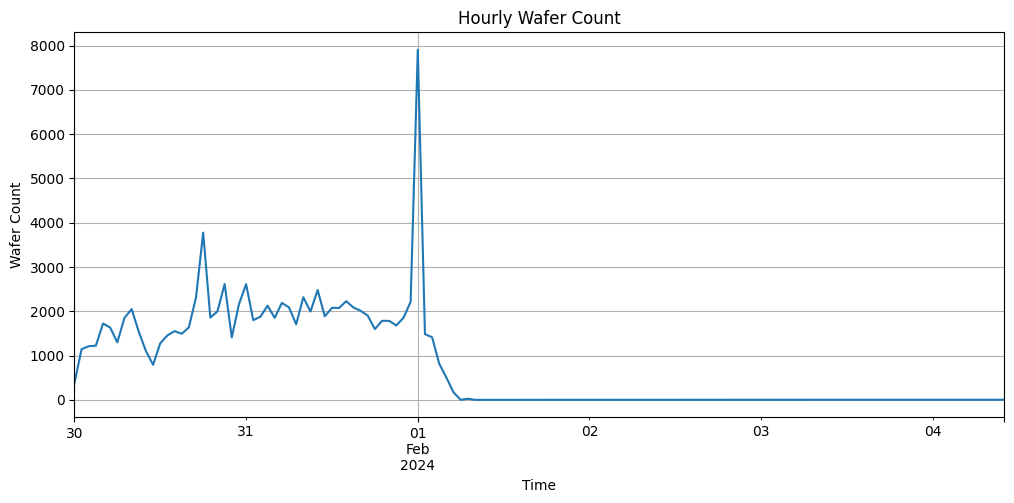

In [7]:
# Step 4. 시계열 데이터 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
hourly.plot()
plt.title("Hourly Wafer Count")
plt.xlabel("Time")
plt.ylabel("Wafer Count")
plt.grid(True)
plt.show()

In [8]:
#Step 5. 정상성 검정 (ADF) Test
from statsmodels.tsa.stattools import adfuller

result = adfuller(hourly)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.171193152434627
p-value: 0.2168662769701864


In [9]:
#Step 6. 훈련용 / 테스트용 분리
train = hourly.iloc[:-24]
test = hourly.iloc[-24:]

print(len(train), len(test))

107 24


In [10]:
#Step 7. ARIMA 모델 후보 비교하기
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

orders = [
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 1),
    (1, 1, 1),
    (2, 1, 1)
]
results = []

for order in orders:
    model = ARIMA(train, order=order)
    fitted = model.fit()
    
    forecast = fitted.forecast(steps=len(test))
    forecast = forecast.clip(lower=0)
    
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    
    results.append([order, fitted.aic, mae, rmse])

result_df = pd.DataFrame(
    results,
    columns=["ARIMA Order", "AIC", "MAE", "RMSE"]
)

print(result_df.sort_values("AIC"))

  ARIMA Order          AIC         MAE        RMSE
4   (1, 1, 1)  1717.656525    0.083415    0.408230
5   (2, 1, 1)  1719.192356    0.089569    0.406884
2   (1, 0, 1)  1733.957359  451.542526  481.887072
3   (2, 0, 1)  1735.816004  415.412300  443.381274
0   (1, 0, 0)  1750.598050  844.652616  860.150025
1   (0, 0, 1)  1783.898860  920.494382  922.478736
